In [1]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score
import missingno as msno


train_csv = pd.read_csv('/kaggle/input/competitions/playground-series-s6e9/train.csv')
test_csv = pd.read_csv('/kaggle/input/competitions/playground-series-s6e9/test.csv')

train_csv.sample(5)

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
158952,158952,59,152781.0,47.1,1,2,9,5.0,Female,Suburban,Sedan,Yes,Yes,Low,Yes
519931,519931,63,65726.0,34.4,1,2,1,5.0,Male,Rural,Sedan,Yes,Yes,Low,Yes
399254,399254,32,84768.0,61.4,3,7,9,1.0,Male,Suburban,Sedan,Yes,Yes,Low,No
492564,492564,43,121294.0,35.4,2,2,2,1.0,Male,Suburban,Sedan,Yes,Yes,Low,No
549478,549478,42,80186.0,52.3,3,4,3,3.0,Male,Suburban,Hatchback,Yes,Yes,Low,Yes


In [2]:
# View train dataset
train_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  object 
 9   City_Type                    668665 non-null  object 
 10  Current_Car_Type             668665 non-null  object 
 11  Home_Charging_Possible       668665 non-null  object 
 12  Subsidy_Available            668665 non-null  object 
 13 

In [3]:
# View test dataset
test_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286571 entries, 0 to 286570
Data columns (total 14 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           286571 non-null  int64  
 1   Age                          286571 non-null  int64  
 2   Annual_Income_USD            286571 non-null  float64
 3   Daily_Commute_km             286571 non-null  float64
 4   Number_of_Cars_Owned         286571 non-null  int64  
 5   Charging_Stations_Near_Home  286571 non-null  int64  
 6   Charging_Stations_Near_Work  286571 non-null  int64  
 7   Environmental_Concern_Level  286571 non-null  float64
 8   Gender                       286571 non-null  object 
 9   City_Type                    286571 non-null  object 
 10  Current_Car_Type             286571 non-null  object 
 11  Home_Charging_Possible       286571 non-null  object 
 12  Subsidy_Available            286571 non-null  object 
 13 

In [4]:
# Check for duplicates
train_csv.duplicated().sum()

np.int64(0)

<Axes: >

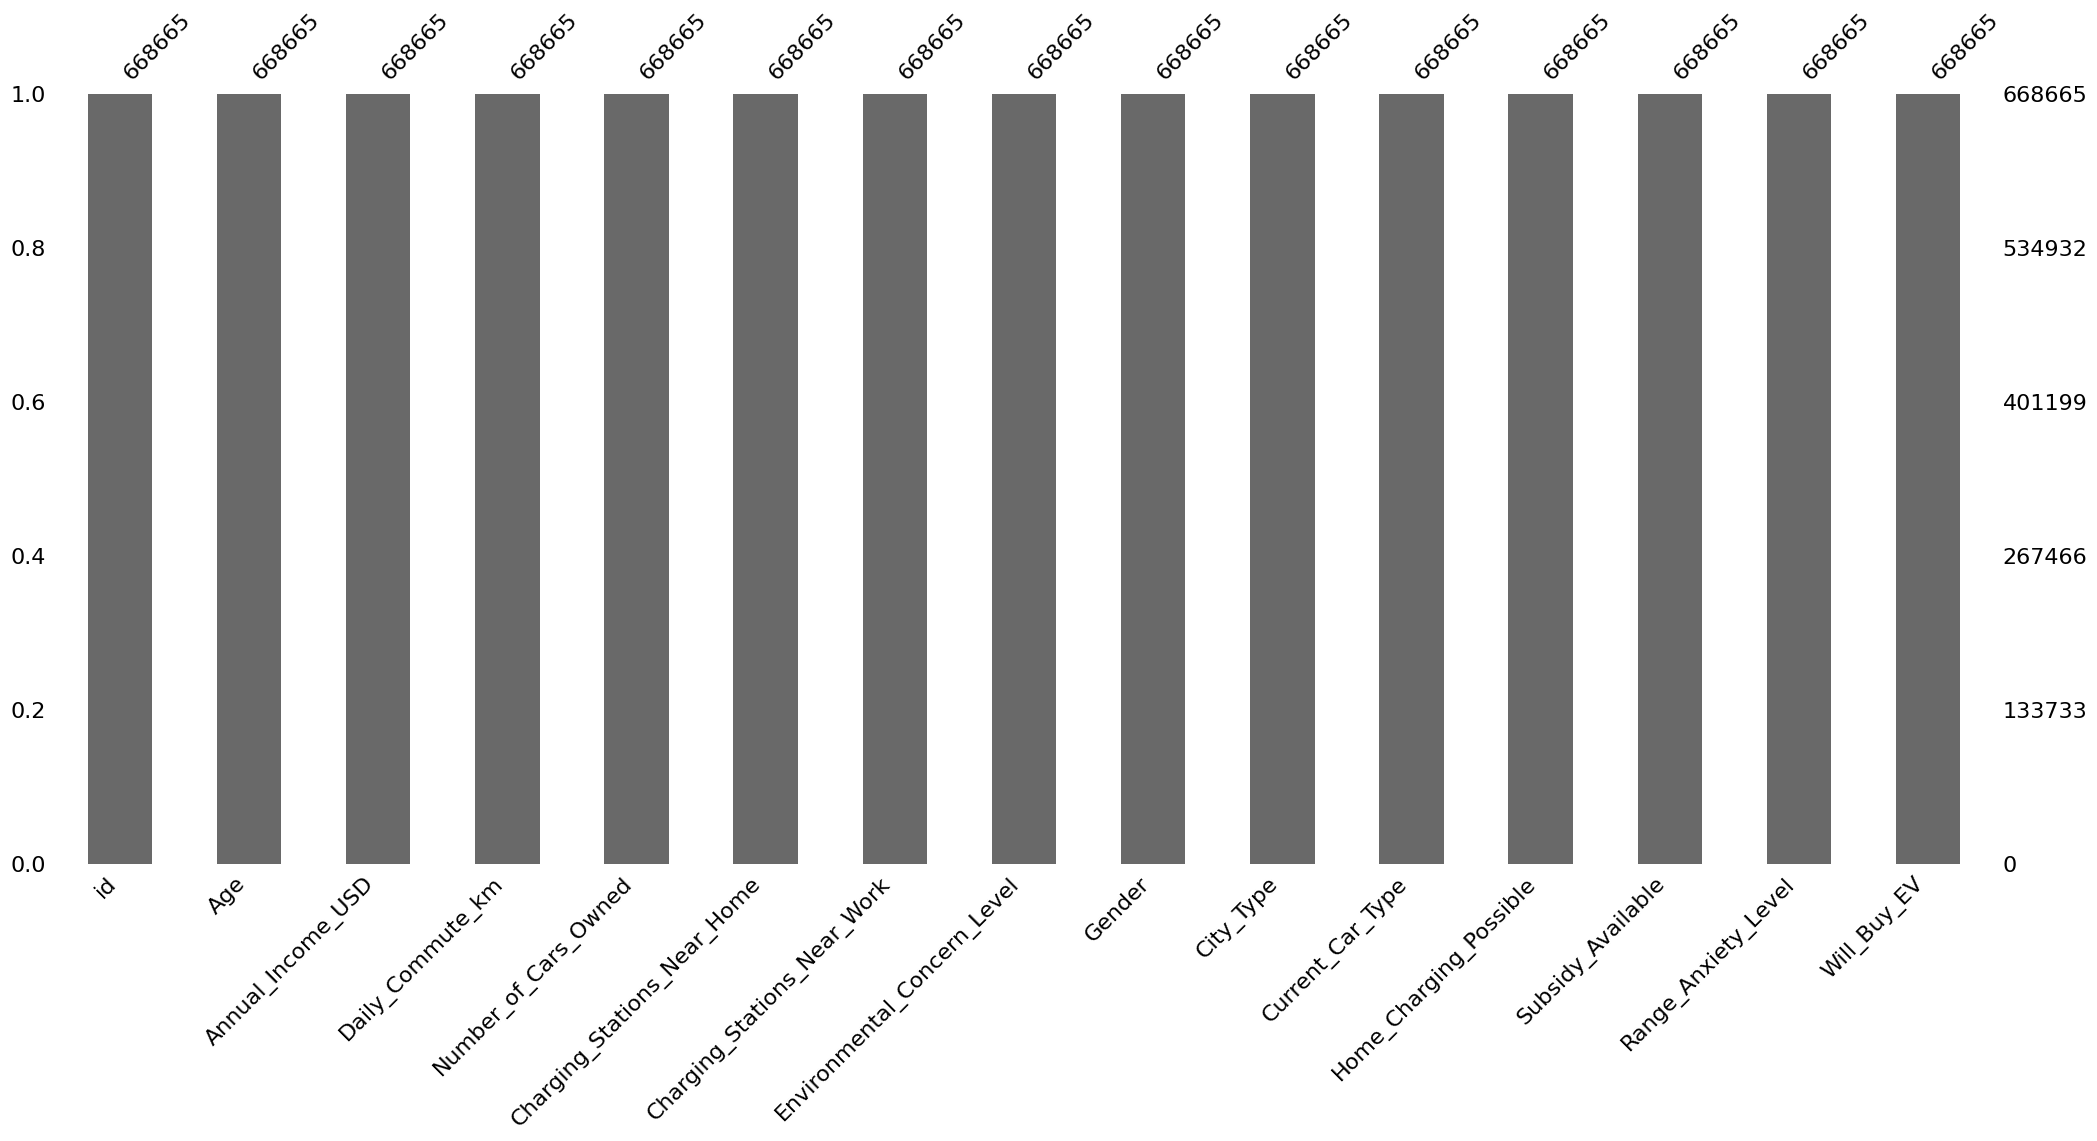

In [5]:
# Check missing values
msno.bar(train_csv)

In [6]:
# Target distribution proportion
yes_target = train_csv['Will_Buy_EV'].value_counts(normalize=True)


print(f' The percentage distribution for: {(yes_target * 100)}')

 The percentage distribution for: Will_Buy_EV
No     82.5355
Yes    17.4645
Name: proportion, dtype: float64


In [7]:
# Look closely at the numerical columns
train_csv.describe().T

,count,mean,std,min,25%,50%,75%,max
id,668665.0,334332.000000,193027.103210,0.0,167166.0,334332.0,501498.0,668664.0
Age,668665.0,47.039171,12.875448,25.0,36.0,47.0,58.0,69.0
Annual_Income_USD,668665.0,84769.266989,28648.029042,30000.0,67376.0,84880.0,102753.0,188549.0
Daily_Commute_km,668665.0,32.158298,18.730474,5.0,17.2,33.6,47.4,98.7
Number_of_Cars_Owned,668665.0,1.712626,0.729275,1.0,1.0,2.0,2.0,4.0
Charging_Stations_Near_Home,668665.0,4.960408,3.926843,0.0,2.0,4.0,7.0,14.0
Charging_Stations_Near_Work,668665.0,7.176314,5.186627,0.0,3.0,6.0,10.0,19.0
Environmental_Concern_Level,668665.0,2.935477,1.429119,1.0,2.0,3.0,4.0,5.0


In [8]:
# Feature Engineering
train_csv['Yearly_Income_to_Vehicle_Ratio'] = (train_csv['Annual_Income_USD'] / (train_csv['Number_of_Cars_Owned']))
test_csv['Yearly_Income_to_Vehicle_Ratio'] = (test_csv['Annual_Income_USD'] / (test_csv['Number_of_Cars_Owned']))
train_csv['Yearly_Income_to_Vehicle_Ratio']

0          46443.5
1          30000.0
2          94389.0
3          36790.0
4          57898.0
            ...   
668660     35545.0
668661     64995.0
668662    121791.0
668663     57961.5
668664     68986.0
Name: Yearly_Income_to_Vehicle_Ratio, Length: 668665, dtype: float64

In [9]:
# Split age into demographic groups
# Youth 25 - 35, Middle Age 36 - 50, Senior 51 - 65, Elder 66+
train_csv.loc[(train_csv['Age'] > 24) & (train_csv['Age'] < 36) , ['Age_Group']] = 'Youth'
train_csv.loc[(train_csv['Age'] > 35) & (train_csv['Age'] < 51) , ['Age_Group']] = 'Middle-Age'
train_csv.loc[(train_csv['Age'] > 50) & (train_csv['Age'] < 65) , ['Age_Group']] = 'Senior'
train_csv.loc[(train_csv['Age'] >= 65) , ['Age_Group']] = 'Elder'

test_csv.loc[(test_csv['Age'] > 24) & (test_csv['Age'] < 36) , ['Age_Group']] = 'Youth'
test_csv.loc[(test_csv['Age'] > 35) & (test_csv['Age'] < 51) , ['Age_Group']] = 'Middle-Age'
test_csv.loc[(test_csv['Age'] > 50) & (test_csv['Age'] < 65) , ['Age_Group']] = 'Senior'
test_csv.loc[(test_csv['Age'] >= 65) , ['Age_Group']] = 'Elder'

train_csv.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV,Yearly_Income_to_Vehicle_Ratio,Age_Group
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No,46443.5,Elder
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No,30000.0,Middle-Age
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes,94389.0,Youth
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No,36790.0,Elder
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No,57898.0,Senior


In [10]:
# Target Encoding
train_csv['Will_Buy_EV'] = train_csv['Will_Buy_EV'].map({'Yes': 1, 'No': 0})

train_csv.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV,Yearly_Income_to_Vehicle_Ratio,Age_Group
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,0,46443.5,Elder
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,0,30000.0,Middle-Age
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,1,94389.0,Youth
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,0,36790.0,Elder
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,0,57898.0,Senior


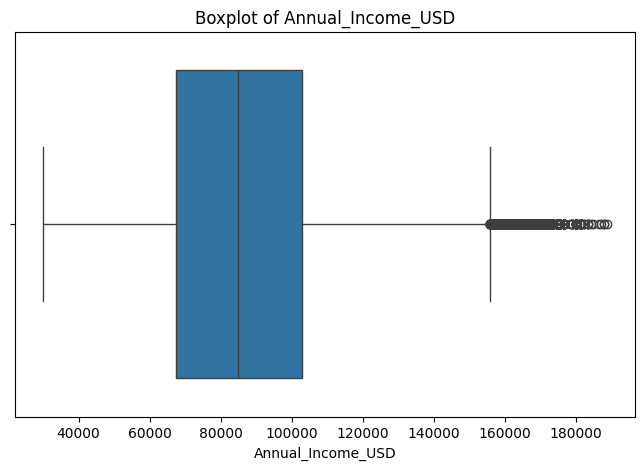

In [11]:
# Boxplot for Annual_Income_USD (Detecting Outliers)
plt.figure(figsize=(8, 5))
sns.boxplot(x=train_csv['Annual_Income_USD'])
plt.title('Boxplot of Annual_Income_USD')
plt.show()

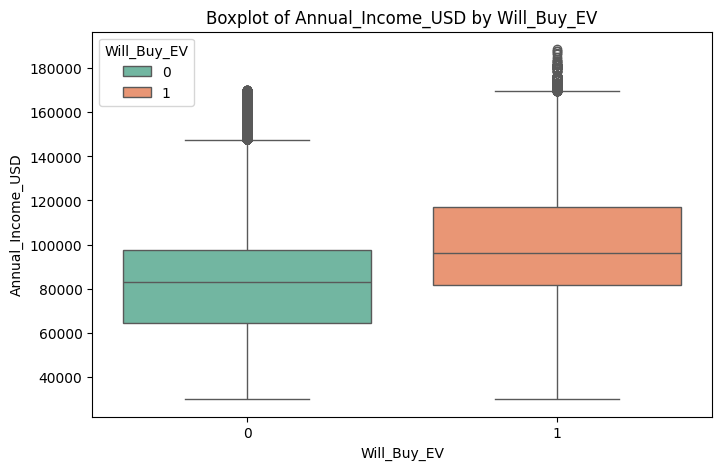

In [12]:
# Lowkey Useless
plt.figure(figsize=(8, 5))
sns.boxplot(x='Will_Buy_EV', y='Annual_Income_USD', data=train_csv, palette='Set2', hue='Will_Buy_EV', legend=True)
plt.title('Boxplot of Annual_Income_USD by Will_Buy_EV')
plt.xlabel('Will_Buy_EV')
plt.ylabel('Annual_Income_USD')
plt.show()

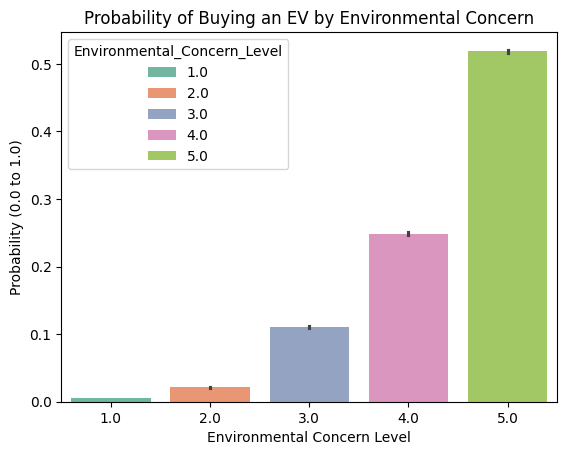

In [13]:
# Viewing the correlation between Environmental concern and buying an EV (Barplot)
sns.barplot(data=train_csv, x='Environmental_Concern_Level', y='Will_Buy_EV', palette='Set2', hue='Environmental_Concern_Level', legend=True)

plt.title('Probability of Buying an EV by Environmental Concern')
plt.ylabel('Probability (0.0 to 1.0)')
plt.xlabel('Environmental Concern Level')
plt.show()

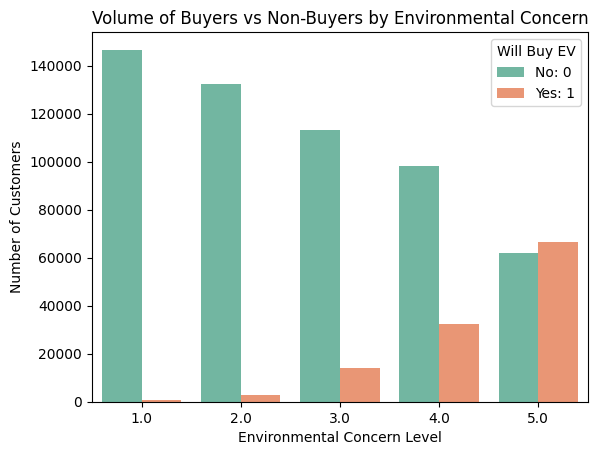

In [14]:
# A countplot to view how many people in each concern level actually bought an EV
sns.countplot(data=train_csv, x='Environmental_Concern_Level', hue='Will_Buy_EV', palette='Set2')

plt.title('Volume of Buyers vs Non-Buyers by Environmental Concern')
plt.ylabel('Number of Customers')
plt.xlabel('Environmental Concern Level')
plt.legend(title='Will Buy EV', labels=['No: 0', 'Yes: 1'])
plt.show()

In [15]:
# Convert the numeric concern level to a string and combine it with the subsidy status
train_csv['Concern_Subsidy_Interaction'] = (
    "Concern_" + train_csv['Environmental_Concern_Level'].astype(str) + 
    "_Subsidy_" + train_csv['Subsidy_Available'].astype(str)
)
test_csv['Concern_Subsidy_Interaction'] = (
    "Concern_" + test_csv['Environmental_Concern_Level'].astype(str) + 
    "_Subsidy_" + test_csv['Subsidy_Available'].astype(str)
)

# Preview the new categories
print(train_csv['Concern_Subsidy_Interaction'].value_counts())

Concern_Subsidy_Interaction
Concern_5.0_Subsidy_Yes    94669
Concern_1.0_Subsidy_Yes    87802
Concern_2.0_Subsidy_Yes    82317
Concern_4.0_Subsidy_Yes    80270
Concern_3.0_Subsidy_Yes    74851
Concern_1.0_Subsidy_No     59674
Concern_2.0_Subsidy_No     52816
Concern_3.0_Subsidy_No     52500
Concern_4.0_Subsidy_No     50199
Concern_5.0_Subsidy_No     33567
Name: count, dtype: int64


In [16]:
# Seperate features from target variable
X = train_csv.drop(columns=['Will_Buy_EV', 'id'])
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 16 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Age                             668665 non-null  int64  
 1   Annual_Income_USD               668665 non-null  float64
 2   Daily_Commute_km                668665 non-null  float64
 3   Number_of_Cars_Owned            668665 non-null  int64  
 4   Charging_Stations_Near_Home     668665 non-null  int64  
 5   Charging_Stations_Near_Work     668665 non-null  int64  
 6   Environmental_Concern_Level     668665 non-null  float64
 7   Gender                          668665 non-null  object 
 8   City_Type                       668665 non-null  object 
 9   Current_Car_Type                668665 non-null  object 
 10  Home_Charging_Possible          668665 non-null  object 
 11  Subsidy_Available               668665 non-null  object 
 12  Range_Anxiety_Le

In [17]:
# Store the target variable
y = train_csv['Will_Buy_EV']

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Convert Numerical Columns
num_cols = ['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Yearly_Income_to_Vehicle_Ratio']

# Convert columns into categorical columns
cat_cols = [
    'Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible', 
    'Subsidy_Available', 'Range_Anxiety_Level', 'Age_Group', 'Concern_Subsidy_Interaction'
] 

# Create the routing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

# 4. Fit and transform strictly on training data, only transform test data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [18]:
# lr = LogisticRegression(max_iter=1000)
# lr.fit(X_train, y_train)
# y_pred_lr = lr.predict(X_test)
# print("Logistic Regression\n", classification_report(y_test, y_pred_lr))
# plot_conf_matrix(y_test, y_pred_lr, "Logistic Regression")
# results.loc[len(results)] = ['Logistic Regression', accuracy_score(y_test, y_pred_lr)]